# About Dataset

link  https://www.kaggle.com/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv/data


I was working on the UTK Dataset and I been through many datasets full of images in different folders which requires a lot of data cleaning and preprocessing.
So I tried to create this dataset in a more simplified manner keeping all the data in the form of a CSV and making it available to everyone.

## imports

In [1]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
import tensorflow as tf

## Load the data

In [2]:
# Download latest version
path = kagglehub.dataset_download("nipunarora8/age-gender-and-ethnicity-face-data-csv")

print("Path to dataset files:", path)

100%|██████████| 63.2M/63.2M [00:00<00:00, 226MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv/versions/1


In [3]:

# The path variable from the previous cell contains the directory where the dataset files are downloaded.
# We can list the files in this directory to find the CSV file.
print("Files in the downloaded directory:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))

csv_file_path = os.path.join(path, "age_gender.csv")

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame
display(df.head())

Files in the downloaded directory:
/root/.cache/kagglehub/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv/versions/1/age_gender.csv


,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


## Preprocessing

In [4]:
df.isnull().sum()

,0
age,0
ethnicity,0
gender,0
img_name,0
pixels,0


In [5]:
df = df.drop("img_name",axis = 1)

In [6]:
df

,age,ethnicity,gender,pixels
0,1,2,0,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,202 205 209 210 209 209 210 211 212 214 218 21...
...,...,...,...,...
23700,99,0,1,127 100 94 81 77 77 74 99 102 98 128 145 160 1...
23701,99,1,1,23 28 32 35 42 47 68 85 98 103 113 117 130 129...
23702,99,2,1,59 50 37 40 34 19 30 101 156 170 177 184 187 1...
23703,99,2,1,45 108 120 156 206 197 140 180 191 199 204 207...


Cluster / set of values based on q = ? mean how much groups you want to make

In [7]:
df["age"] = pd.qcut(df["age"], q =4 ,labels=[0,1,2,3,])

In [8]:
df

,age,ethnicity,gender,pixels
0,0,2,0,129 128 128 126 127 130 133 135 139 142 145 14...
1,0,2,0,164 74 111 168 169 171 175 182 184 188 193 199...
2,0,2,0,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,0,2,0,193 197 198 200 199 200 202 203 204 205 208 21...
4,0,2,0,202 205 209 210 209 209 210 211 212 214 218 21...
...,...,...,...,...
23700,3,0,1,127 100 94 81 77 77 74 99 102 98 128 145 160 1...
23701,3,1,1,23 28 32 35 42 47 68 85 98 103 113 117 130 129...
23702,3,2,1,59 50 37 40 34 19 30 101 156 170 177 184 187 1...
23703,3,2,1,45 108 120 156 206 197 140 180 191 199 204 207...


determine the hight width and pixels of the images

In [9]:
len(df["pixels"][0]. split(" "))   # len of first image

2304

In [10]:
np.sqrt(2304)

np.float64(48.0)

In [11]:
num_pixels = 2304
img_height = 48
img_width = 48

In [12]:
target_columns = ['gender', 'ethnicity', 'age']

y = df[target_columns]
X = df.drop(target_columns, axis=1)

reshape it in 2d to feed it to our nns

In [13]:
X = pd.Series(df['pixels'])
X = X.apply(lambda x: x.split(' '))
X = X.apply(lambda x: np.array(list(map(lambda z: int(z), x))))
X = np.array(X)
X = np.stack(np.array(X), axis=0)
X = np.reshape(X, (-1, 48, 48))

X.shape

(23705, 48, 48)

## See the images

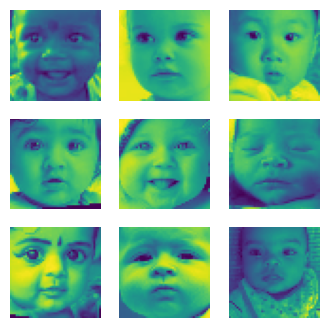

In [14]:
plt.figure(figsize=(4,4))

for index, image in enumerate(np.random.randint(100, 1000, 9)): # select Random imgs from 100 to 1000 and show any 9 of those
    plt.subplot(3, 3, index + 1)
    plt.imshow(X[image])
    plt.axis('off')

plt.show()

##Training

In [15]:
y_gender = np.array(y['gender'])
y_ethnicity = np.array(y['ethnicity'])
y_age = np.array(y['age'])

Rescaling → normalize input pixels.

Conv2D (16 filters, 3x3) → detect features (edges, textures).

MaxPooling2D → reduce size, keep strongest features.

In [16]:
def model(num_classes, activation = "softmax",loss="sparse_categorical_crossentropy"):

  inputs = tf.keras.Input(shape=(img_height,img_width,1))

  x = layers.Rescaling(1./255)(inputs)  # convert the values to 0 anmd 1 these one = [129 128 128 126 127 130 133 135]
  x = layers.Conv2D(16,3, padding = "same", activation="relu")(x)
  x = layers.MaxPooling2D()(x)
  x = layers.Conv2D(32,3, padding = "same" , activation ="relu")(x)
  x = layers.MaxPooling2D()(x)
  x = layers.Conv2D(64,3, padding = "same" , activation ="relu")(x)
  x = layers.MaxPooling2D()(x)
  x = layers.Flatten()(x)
  x = layers.Dense(128, activation='relu')(x)
  outputs = layers.Dense(num_classes, activation=activation)(x)



  model = tf.keras.Model(inputs=inputs, outputs=outputs)



  model.compile(
      optimizer="Adam",
      loss=loss,
      metrics=["accuracy"]
  )


  return model

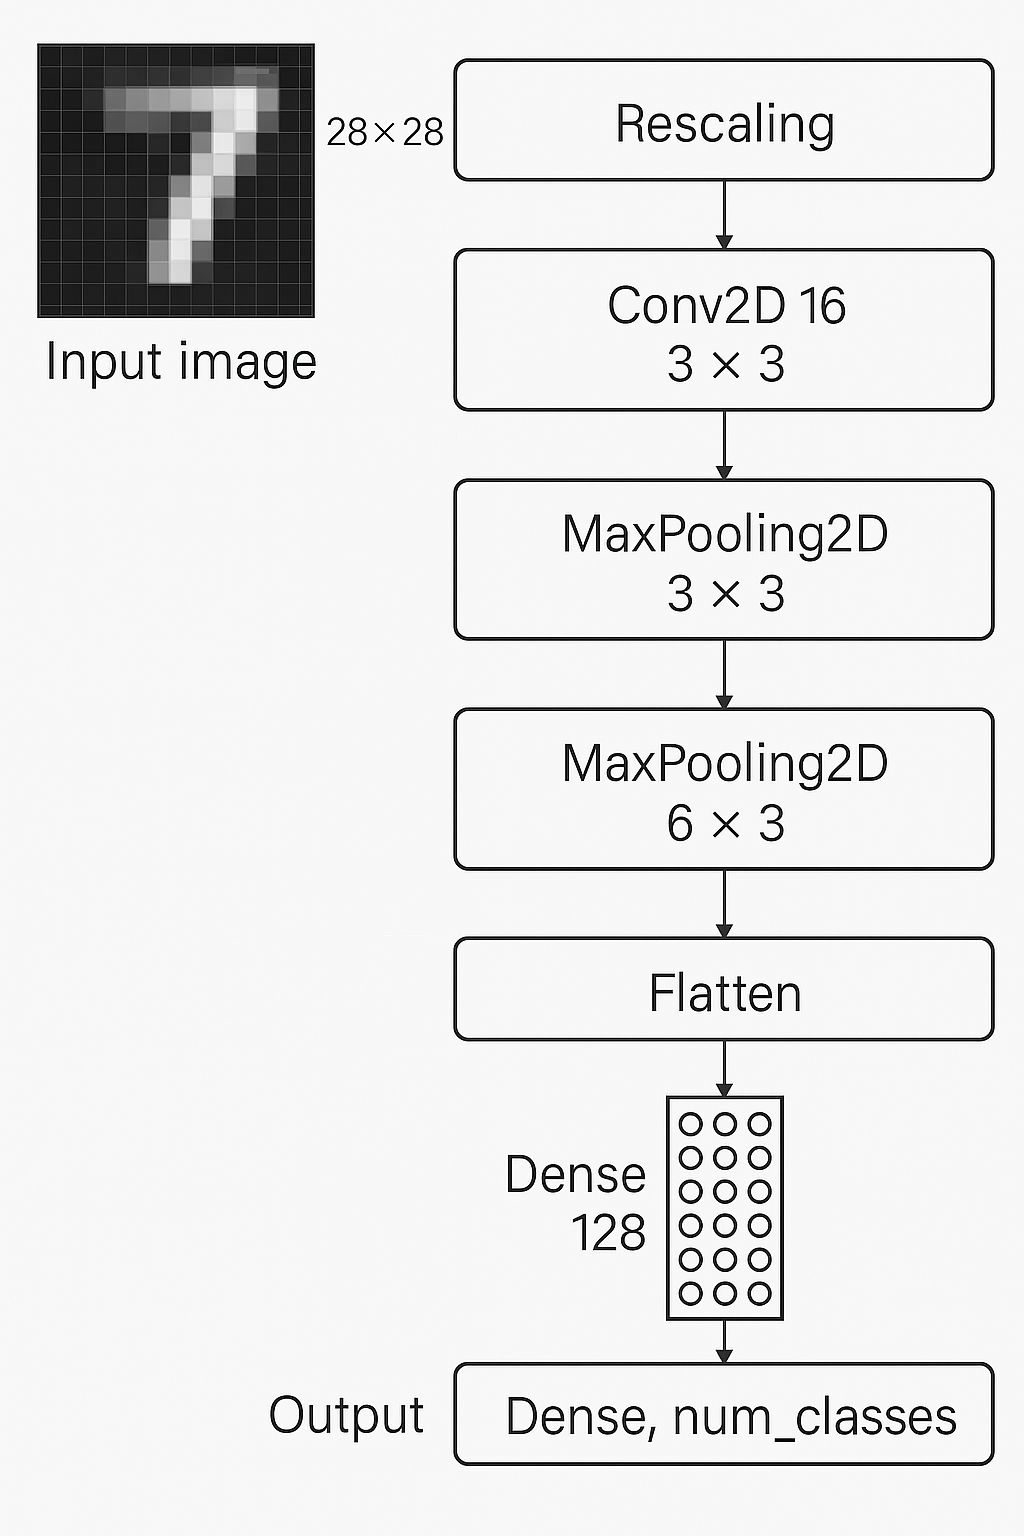

In [17]:
X_gender_train, X_gender_test, y_gender_train, y_gender_test = train_test_split(X, y_gender, train_size=0.7)


X_ethnicity_train, X_ethnicity_test, y_ethnicity_train, y_ethnicity_test = train_test_split(X, y_ethnicity, train_size=0.7)


X_age_train, X_age_test, y_age_train, y_age_test = train_test_split(X, y_age, train_size=0.7)

## Gender Model

In [18]:
gender_model = model(1, activation='sigmoid', loss='binary_crossentropy')

gender_history = gender_model.fit(

                                    X_gender_train,y_gender_train,
                                    validation_split=0.2,
                                    batch_size=64,
                                    epochs= 10,
                                    callbacks=[tf.keras.callbacks.ReduceLROnPlateau()],
                                    verbose=0

)

In [19]:
fig = px.line(
    gender_history.history,
    y=['loss', 'val_loss'],
    labels={'index': "Epoch", 'value': "Loss"},
    title="Gender Model"
)

fig.show()

##Ethnicity Model

In [41]:
ethnicity_model = model(5, activation='softmax', loss='sparse_categorical_crossentropy')

ethnicity_history = ethnicity_model.fit(
    X_ethnicity_train,
    y_ethnicity_train,
    validation_split=0.2,
    batch_size=64,
    epochs=10,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau()],
    verbose=0
)

In [42]:
fig = px.line(
    ethnicity_history.history,
    y=['loss', 'val_loss'],
    labels={'index': "Epoch", 'value': "Loss"},
    title="Ethnicity Model"
)

fig.show()

## Age model

In [39]:
age_model = model(4, activation='softmax', loss='sparse_categorical_crossentropy')

age_history = age_model.fit(
    X_age_train,
    y_age_train,
    validation_split=0.2,
    batch_size=64,
    epochs=10,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau()],
    verbose=0
)

In [40]:
fig = px.line(
    age_history.history,
    y=['loss', 'val_loss'],
    labels={'index': "Epoch", 'value': "Loss"},
    title="Age Model"
)

fig.show()

## Results

In [29]:
gender_acc = gender_model.evaluate(X_gender_test, y_gender_test)[1]

223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8884 - loss: 0.2824


In [43]:
ethnicity_acc = ethnicity_model.evaluate(X_ethnicity_test, y_ethnicity_test)[1]

223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7692 - loss: 0.6617


In [44]:
age_acc = age_model.evaluate(X_age_test, y_age_test)[1]

223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6193 - loss: 0.8865


In [46]:
fig = px.histogram(
    x=["Gender", "Ethnicity", "Age"],
    y=[gender_acc, ethnicity_acc, age_acc],
    labels={'x': "", 'y': "Accuracy"},
    color=["Gender", "Ethnicity", "Age"],
    title="Model Performance"
)

fig.show()